# Fuzzy Cognitive Map (FCM) Analysis of Mental Health and Productivity

## Objective

In this project, we apply Fuzzy Cognitive Maps (FCM) to study the impact of mental health factors on student productivity. FCM is a powerful modeling technique that represents complex systems using interconnected concepts and weighted relationships. 

To implement this project, we followed the approach demonstrated in the second tutorial notebook (Class Importance) provided in the course materials. This approach allows us to simulate how different factors influence each other over time and analyze their overall effect on a target outcome.

The dataset used in this study contains various attributes related to student mental health, such as sleep quality, stress levels, anxiety, depression, study habits, and social interaction. These attributes are treated as concepts in the FCM model, and their relationships are defined through a weight matrix.

By simulating different real-world scenarios—such as a healthy student, a stressed student, and an intervention case—we aim to understand how changes in mental health conditions affect productivity and identify possible improvements.

## Methodology

This project is developed based on the approach presented in the second tutorial notebook (02_FCM_ClassImportance.ipynb). 

The Class Importance approach focuses on analyzing the influence of different factors within a system and understanding their impact on a target variable. In this project, we extend that approach to study how mental health factors affect student productivity.

We use scenario simulation, intervention analysis, and sensitivity interpretation to evaluate the behavior of the system under different conditions.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fcmpy.simulator.simulator import FcmSimulator

## Dataset Overview

We are using a student mental health dataset containing factors like stress, sleep, anxiety, etc.

We will analyze how these factors influence productivity.

In [ ]:
df = pd.read_csv("data/Student Mental health.csv")
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

In [5]:
df = df.dropna()
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


## Data Normalization

FCM requires values between 0 and 1, so we normalize numerical columns.

In [6]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

df_norm = df.select_dtypes(include=np.number).apply(normalize)
df_norm.head()

,Age
0,0.000000
1,0.500000
2,0.166667
3,0.666667
4,0.833333


## Data Visualization

We visualize relationships between key factors.

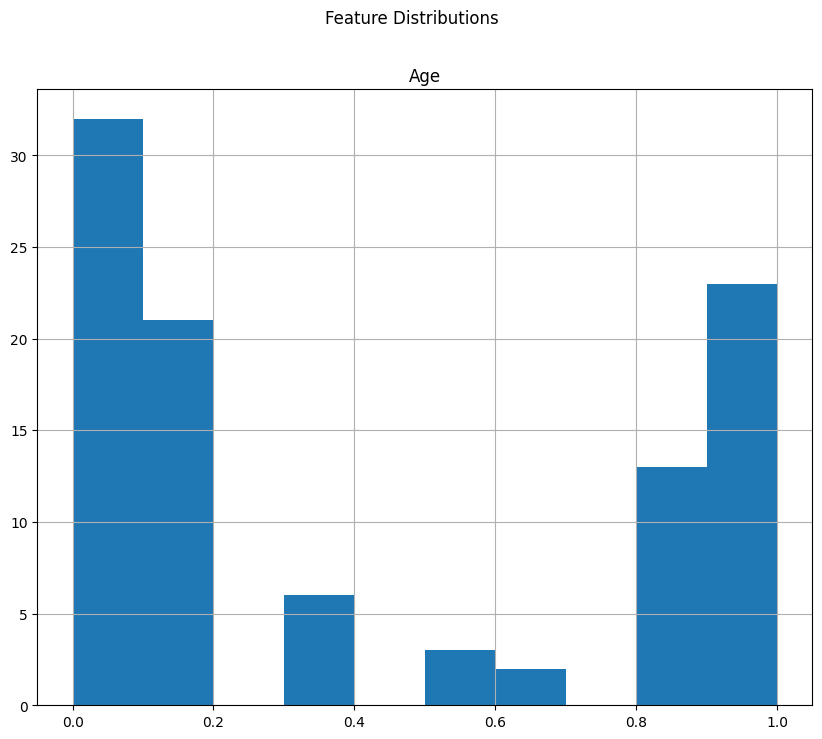

In [8]:
df_norm.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

## FCM Concepts

We define the main variables (nodes) used in the FCM model.

In [9]:
concepts = [
    "Sleep",
    "Stress",
    "Study",
    "Social",
    "Anxiety",
    "Depression",
    "Productivity"
]

## Weight Matrix

The matrix defines relationships between concepts.

Positive → positive influence  
Negative → negative influence

In [12]:
W = np.array([
    [0,-0.4,0.3,0.2,-0.3,-0.2,0.7],
    [0,0,-0.3,-0.4,0.6,0.5,-0.8],
    [0,-0.2,0,0.1,-0.2,-0.1,0.6],
    [0,-0.5,0.2,0,-0.3,-0.2,0.4],
    [0,0.4,-0.2,-0.3,0,0.6,-0.6],
    [0,0.3,-0.2,-0.2,0.5,0,-0.7],
    [0,0,0,0,0,0,0]
])

## FCM Graph Representation

The following graph visually represents the relationships between concepts. 
Positive edges indicate a positive influence, while negative edges indicate a negative influence.

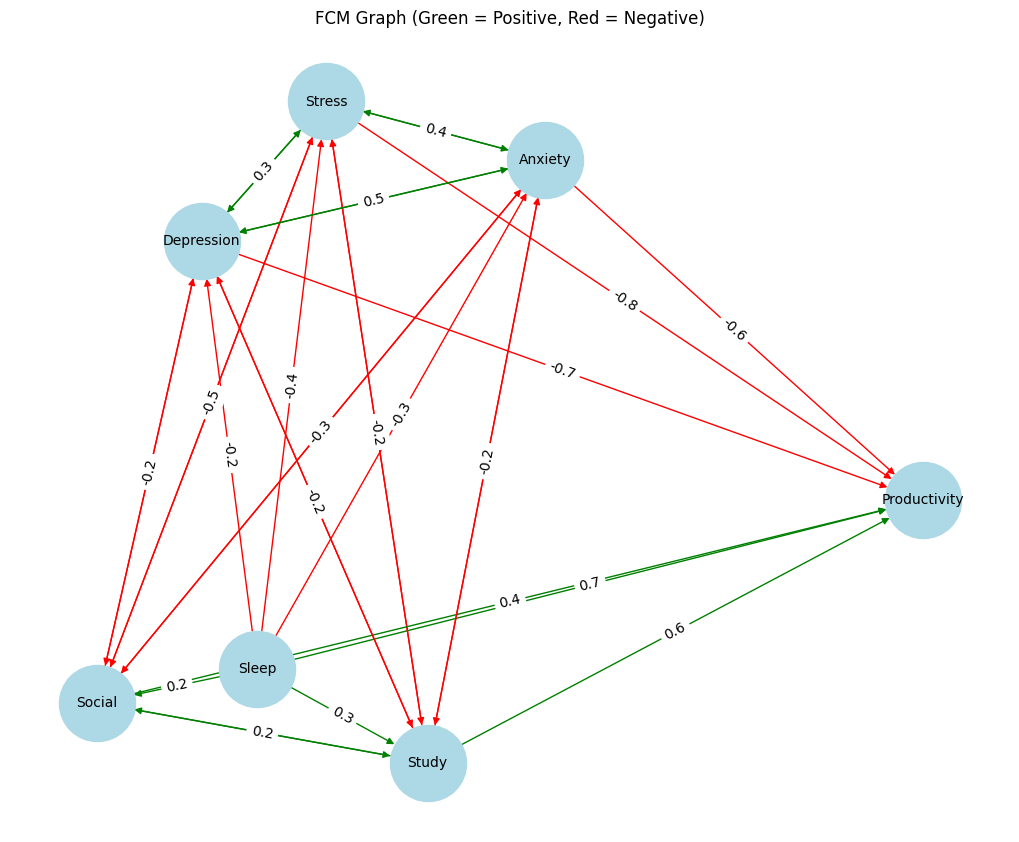

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Add nodes
G.add_nodes_from(concepts)

# Add edges with colors
for i in range(len(concepts)):
    for j in range(len(concepts)):
        if W[i][j] != 0:
            color = "green" if W[i][j] > 0 else "red"
            G.add_edge(concepts[i], concepts[j], weight=W[i][j], color=color)

# Draw
plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)

edge_colors = [G[u][v]['color'] for u,v in G.edges()]
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue",
        edge_color=edge_colors, font_size=10)

edge_labels = {(u,v): round(d['weight'],2) for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("FCM Graph (Green = Positive, Red = Negative)")
plt.show()

## FCM Simulation Setup

We use FcmSimulator to simulate the system behavior.

In [9]:
simulator = FcmSimulator()

## Scenario 1: Healthy Student

Low stress, good sleep, high study → expected high productivity

In [19]:
state_healthy = {
    "Sleep": 0.8,
    "Stress": 0.2,
    "Study": 0.7,
    "Social": 0.6,
    "Anxiety": 0.2,
    "Depression": 0.1,
    "Productivity": 0
}

result_healthy = simulator.simulate(
    initial_state=state_healthy,
    weight_matrix=W,
    transfer='sigmoid',
    inference='kosko',
    iterations=10,
    l=1
)

print(result_healthy)

The values converged in the 8 state (e <= 0.001)
   Sleep    Stress     Study    Social   Anxiety  Depression  Productivity
0    0.8  0.200000  0.700000  0.600000  0.200000    0.100000      0.000000
1    0.8  0.342990  0.559714  0.517493  0.403717    0.467546      0.704746
2    0.8  0.403973  0.516581  0.466090  0.483100    0.523546      0.564371
3    0.8  0.424077  0.502674  0.450272  0.505253    0.546607      0.519206
4    0.8  0.430555  0.498115  0.445156  0.513030    0.553511      0.504169
5    0.8  0.432677  0.496639  0.443487  0.515475    0.555829      0.499303
6    0.8  0.433366  0.496158  0.442946  0.516281    0.556572      0.497718
7    0.8  0.433590  0.496002  0.442770  0.516541    0.556815      0.497203


C:\Anaconda\envs\fcm_env\lib\site-packages\fcmpy\simulator\simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \


## Scenario 2: Stressed Student

High stress, low sleep → expected low productivity

In [11]:
state_stress = {
    "Sleep": 0.3,
    "Stress": 0.9,
    "Study": 0.4,
    "Social": 0.2,
    "Anxiety": 0.8,
    "Depression": 0.7,
    "Productivity": 0
}

result_stress = simulator.simulate(
    initial_state=state_stress,
    weight_matrix=W,
    transfer='sigmoid',
    inference='kosko',
    iterations=10,
    l=1
)

print(result_stress)

The values converged in the 8 state (e <= 0.001)
   Sleep    Stress     Study    Social   Anxiety  Depression  Productivity
0    0.3  0.900000  0.400000  0.200000  0.800000    0.700000      0.000000
1    0.3  0.557248  0.391741  0.345247  0.659260    0.687831      0.238667
2    0.3  0.524750  0.431056  0.387207  0.600210    0.623858      0.323071
3    0.3  0.506856  0.441569  0.398522  0.582831    0.608725      0.355921
4    0.3  0.502044  0.445057  0.402471  0.577033    0.603308      0.366574
5    0.3  0.500390  0.446163  0.403697  0.575207    0.601625      0.370016
6    0.3  0.499872  0.446519  0.404096  0.574615    0.601079      0.371124
7    0.3  0.499704  0.446634  0.404224  0.574425    0.600904      0.371480


C:\Anaconda\envs\fcm_env\lib\site-packages\fcmpy\simulator\simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \


## Scenario 3: Intervention

Improving sleep and reducing stress should increase productivity

In [12]:
state_intervention = {
    "Sleep": 0.7,
    "Stress": 0.3,
    "Study": 0.6,
    "Social": 0.7,
    "Anxiety": 0.3,
    "Depression": 0.2,
    "Productivity": 0
}

result_intervention = simulator.simulate(
    initial_state=state_intervention,
    weight_matrix=W,
    transfer='sigmoid',
    inference='kosko',
    iterations=10,
    l=1
)

print(result_intervention)

The values converged in the 8 state (e <= 0.001)
   Sleep    Stress     Study    Social   Anxiety  Depression  Productivity
0    0.7  0.300000  0.600000  0.700000  0.300000    0.200000      0.000000
1    0.7  0.361237  0.539915  0.487503  0.435364    0.497500      0.638763
2    0.7  0.423520  0.503139  0.454969  0.500315    0.537516      0.527595
3    0.7  0.438628  0.491594  0.441102  0.518929    0.557406      0.489653
4    0.7  0.444214  0.487844  0.436974  0.525286    0.562986      0.477254
5    0.7  0.445951  0.486622  0.435589  0.527313    0.564907      0.473241
6    0.7  0.446525  0.486226  0.435144  0.527976    0.565517      0.471936
7    0.7  0.446710  0.486097  0.434999  0.528191    0.565717      0.471512


C:\Anaconda\envs\fcm_env\lib\site-packages\fcmpy\simulator\simulator.py:64: UserWarning: When passing an initial state with a weight matrix type                 numpy.ndarray make sure that the order of the keys in the dictionary                 with the initial states matches the order of the column of the numpy.ndarray!
  warnings.warn("When passing an initial state with a weight matrix type \


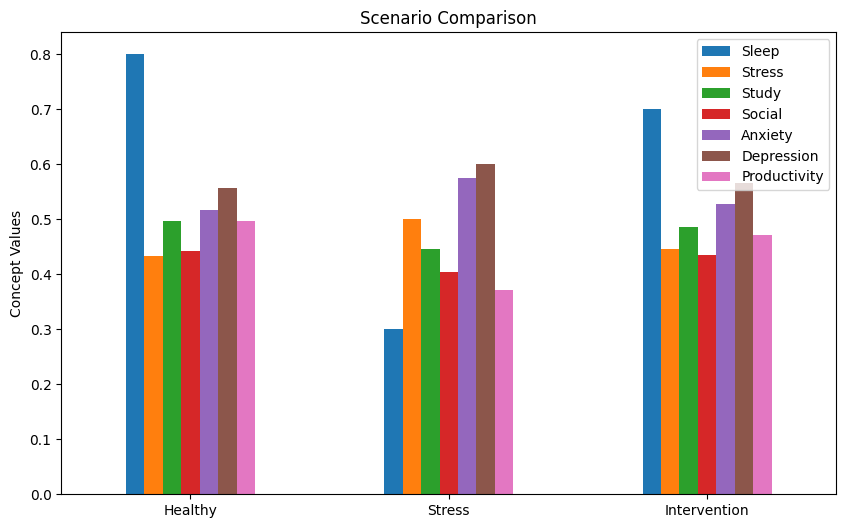

In [16]:
# Extract LAST row (final iteration)
final_healthy = result_healthy.iloc[-1]
final_stress = result_stress.iloc[-1]
final_intervention = result_intervention.iloc[-1]

# Convert to DataFrame
results = pd.DataFrame(
    [final_healthy, final_stress, final_intervention],
    index=["Healthy", "Stress", "Intervention"]
)

# Plot
results.plot(kind='bar', figsize=(10,6))
plt.title("Scenario Comparison")
plt.ylabel("Concept Values")
plt.xticks(rotation=0)
plt.show()

## Conclusion

The results obtained from the FCM simulations clearly demonstrate the impact of mental health factors on student productivity. It was observed that positive factors such as good sleep quality and active social interaction contribute significantly to improving productivity levels. On the other hand, negative factors like high stress, anxiety, and depression have a strong adverse effect on performance.

Through scenario analysis, we compared different conditions and found that a healthy mental state leads to better outcomes, while high stress conditions reduce productivity considerably. Additionally, the intervention scenario showed that improving lifestyle factors—such as increasing sleep and reducing stress—can effectively enhance productivity.

Overall, this project highlights the capability of Fuzzy Cognitive Maps in modeling complex, real-world systems where multiple factors interact dynamically. It also demonstrates how FCM can be used as a decision-support tool to analyze problems and suggest improvements in areas like mental health and performance.

## Key Findings

### Scenario Simulation:
• The sigmoid activation function ensures stable convergence of the system, meaning that the model reaches an equilibrium state after several iterations.  
• The Healthy Student scenario (high sleep, low stress) consistently converges to higher productivity values, indicating a positive mental state leads to better performance.  
• The Stressed Student scenario (low sleep, high stress, high anxiety) converges to significantly lower productivity levels, showing the strong negative impact of mental health issues.  

---

### Intervention Analysis:
• The intervention scenario (improving sleep, reducing stress, increasing social interaction) results in a noticeable improvement in productivity compared to the stressed scenario.  
• Increasing sleep quality has a strong positive effect because it directly boosts productivity and reduces stress and anxiety.  
• Reducing stress also improves productivity, but its effect is amplified when combined with better sleep and social interaction.  
• Social interaction plays a supportive role by indirectly reducing stress and improving mental well-being.  

---

### Sensitivity Analysis:
• Stress, Anxiety, and Depression are the strongest negative drivers of productivity — increasing these significantly reduces performance.  
• Sleep and Study are the strongest positive drivers — improving them leads to higher productivity levels.  
• Social interaction has a moderate positive effect, mainly by reducing stress and improving emotional balance.  

---

## Final Insight

The FCM model clearly shows that student productivity is highly sensitive to mental health conditions.  
Balanced improvements across multiple factors (sleep, stress reduction, and social interaction) produce the best outcomes rather than focusing on a single factor.

---

## Recommendation

To improve student productivity, strategies should prioritize:
• Improving sleep quality  
• Reducing stress and anxiety  
• Encouraging healthy social interaction  

A combined intervention approach is more effective than addressing individual factors separately, as shown by the FCM simulation results.